In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.cluster import KMeans

In [7]:
customer_features = pd.read_csv('customer_features.csv')
print(f"Loaded: {customer_features.shape[0]:,} customers × {customer_features.shape[1]} features")
print(f"Churn rate: {customer_features['churned'].mean()*100:.1f}%")

Loaded: 93,350 customers × 32 features
Churn rate: 58.9%


In [8]:
customer_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93350 entries, 0 to 93349
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               93350 non-null  int64  
 1   customer_unique_id       93350 non-null  object 
 2   total_orders             93350 non-null  int64  
 3   total_spend              93350 non-null  float64
 4   avg_order_value          93350 non-null  float64
 5   max_order_value          93350 non-null  float64
 6   min_order_value          93350 non-null  float64
 7   first_purchase           93350 non-null  object 
 8   last_purchase            93350 non-null  object 
 9   avg_review_score         92747 non-null  float64
 10  min_review_score         92747 non-null  float64
 11  avg_delivery_days        93350 non-null  float64
 12  pct_on_time              93350 non-null  float64
 13  favorite_category        93350 non-null  object 
 14  num_categories        

In [5]:
# PREPARE FEATURES FOR CLUSTERING
# ============================================================
# WHY: We use only RFM features for segmentation — these are the 3 features
#      Using all features would create segments that are harder to explain.

from sklearn.preprocessing import StandardScaler

rfm_features = customer_features[['recency_days', 'total_orders', 'total_spend']].copy()
rfm_features.columns = ['Recency (days)', 'Frequency (orders)', 'Monetary (spend)']

# Scale features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

print("RFM features shape:", rfm_features.shape)
print("\nBefore scaling (first 5 rows):")
print(rfm_features.head(5))
print("\nAfter scaling (first 5 rows):")
print(pd.DataFrame(rfm_scaled[:5], columns=rfm_features.columns).round(3))
# Notice: all values are now on the same scale (roughly -2 to +2)

RFM features shape: (93350, 3)

Before scaling (first 5 rows):
   Recency (days)  Frequency (orders)  Monetary (spend)
0             111                   1            141.90
1             114                   1             27.19
2             536                   1             86.22
3             320                   1             43.62
4             287                   1            196.89

After scaling (first 5 rows):
   Recency (days)  Frequency (orders)  Monetary (spend)
0          -0.825               -0.16            -0.103
1          -0.806               -0.16            -0.610
2           1.960               -0.16            -0.349
3           0.544               -0.16            -0.537
4           0.328               -0.16             0.140


In [ ]:

#  FINDING OPTIMAL NUMBER OF CLUSTERS (ELBOW + SILHOUETTE)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
K_range = range(2, 11)

# This loop takes ~2-3 minutes. Watch it run while you read the mini-tutorial above.
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))
    print(f"K={k}: Inertia={kmeans.inertia_:,.0f}, Silhouette={silhouette_scores[-1]:.3f}")

# Plot both methods
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method\n(Look for the "elbow" — where improvement slows)', fontweight='bold')

ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score\n(Higher = better defined clusters)', fontweight='bold')

plt.tight_layout()
plt.savefig('kmeans_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

# What to look for:
# Elbow: usually around K=4 for RFM data
# Silhouette: usually peaks at K=3 or K=4

In [7]:
# I choose 4 because the dataset has majority of 1 time buyers with a narrow spending range for a majority of them 


optimal_k = 4  
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customer_features['cluster'] = kmeans_final.fit_predict(rfm_scaled)

print(f"Cluster distribution:")
print(customer_features['cluster'].value_counts())

Cluster distribution:
cluster
0    50636
1    37524
3     2772
2     2418
Name: count, dtype: int64


In [8]:
# This is the "interpretation" step. with optimal_k =4 

cluster_profile = customer_features.groupby('cluster').agg(customer_count=('customer_unique_id', 'count'),median_recency=('recency_days', 'median'),
    median_orders=('total_orders', 'median'),
    median_spend=('total_spend', 'median'),
    churn_rate=('churned', 'mean')).round(2)

cluster_profile['pct_of_customers'] = (cluster_profile['customer_count'] / len(customer_features) * 100).round(1)

print("CLUSTER PROFILES:")
print(cluster_profile.to_string())

CLUSTER PROFILES:
         customer_count  median_recency  median_orders  median_spend  churn_rate  pct_of_customers
cluster                                                                                           
0                 50636           128.0            1.0        103.64        0.29              54.2
1                 37524           373.0            1.0        101.34        1.00              40.2
2                  2418           224.0            1.0        935.94        0.58               2.6
3                  2772           198.0            2.0        223.90        0.56               3.0


### cluster 0 : lot of customers , within (127 days) the churn limit of 180 days , spend is between 40th and 60th percentile ,have a low churn rate = "Active Casual Customers"
### cluster 1 : again a big number of customers(37,524) , who have not made a recent purchase ,  spend is between 40th and 60th percentile, almost everyone is churned = Lost/Inactive customers and also includes some of the At-Risk customers : "LOST Customer"
### cluster 2 : less in number (2418) , have become churned ( 224 days), spend highly , have a significant churning rate( characteristic of the dataset) = "High Value At-Risk" 
### cluster 3 : again less in number(2772) , have just become churned (198 days),they also spend highly, they order multiple times  , have a high churning rate(0.56) = "Loyal Repeat At-Risk"

In [9]:
customer_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93350 entries, 0 to 93349
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_unique_id       93350 non-null  object 
 1   total_orders             93350 non-null  int64  
 2   total_spend              93350 non-null  float64
 3   avg_order_value          93350 non-null  float64
 4   max_order_value          93350 non-null  float64
 5   min_order_value          93350 non-null  float64
 6   first_purchase           93350 non-null  object 
 7   last_purchase            93350 non-null  object 
 8   avg_review_score         92747 non-null  float64
 9   min_review_score         92747 non-null  float64
 10  avg_delivery_days        93350 non-null  float64
 11  pct_on_time              93350 non-null  float64
 12  num_categories           93350 non-null  int64  
 13  state                    93350 non-null  object 
 14  recency_days          

In [10]:
segment_map = {
    0: "Active Casual Customers",
    1: "Lost Customers",
    2: "High Value - At Risk Customers",
    3: "Loyal Repeat - At Risk Customers"
}

customer_features["segment"] = customer_features["cluster"].map(segment_map)

In [11]:
customer_features.head()

,customer_unique_id,total_orders,total_spend,avg_order_value,max_order_value,min_order_value,first_purchase,last_purchase,avg_review_score,min_review_score,...,state,recency_days,customer_age_days,avg_days_between_orders,order_value_range,spend_per_active_day,churned,has_repeat_orders,cluster,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,141.90,141.90,2018-05-10 10:56:27,2018-05-10 10:56:27,5.0,5.0,...,SP,111,1,NaN,141.90,141.90,0,0,0,Active Casual Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,27.19,27.19,2018-05-07 11:11:27,2018-05-07 11:11:27,4.0,4.0,...,SP,114,1,NaN,27.19,27.19,0,0,0,Active Casual Customers
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,86.22,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03,3.0,3.0,...,SC,536,1,NaN,86.22,86.22,1,0,1,Lost Customers
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,43.62,43.62,2017-10-12 20:29:41,2017-10-12 20:29:41,4.0,4.0,...,PA,320,1,NaN,43.62,43.62,1,0,1,Lost Customers
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,196.89,196.89,2017-11-14 19:45:42,2017-11-14 19:45:42,5.0,5.0,...,SP,287,1,NaN,196.89,196.89,1,0,1,Lost Customers


In [12]:
print(customer_features['segment'].value_counts())


segment
Active Casual Customers             50636
Lost Customers                      37524
Loyal Repeat - At Risk Customers     2772
High Value - At Risk Customers       2418
Name: count, dtype: int64


Variance explained by 2 PCA components: 70.8%


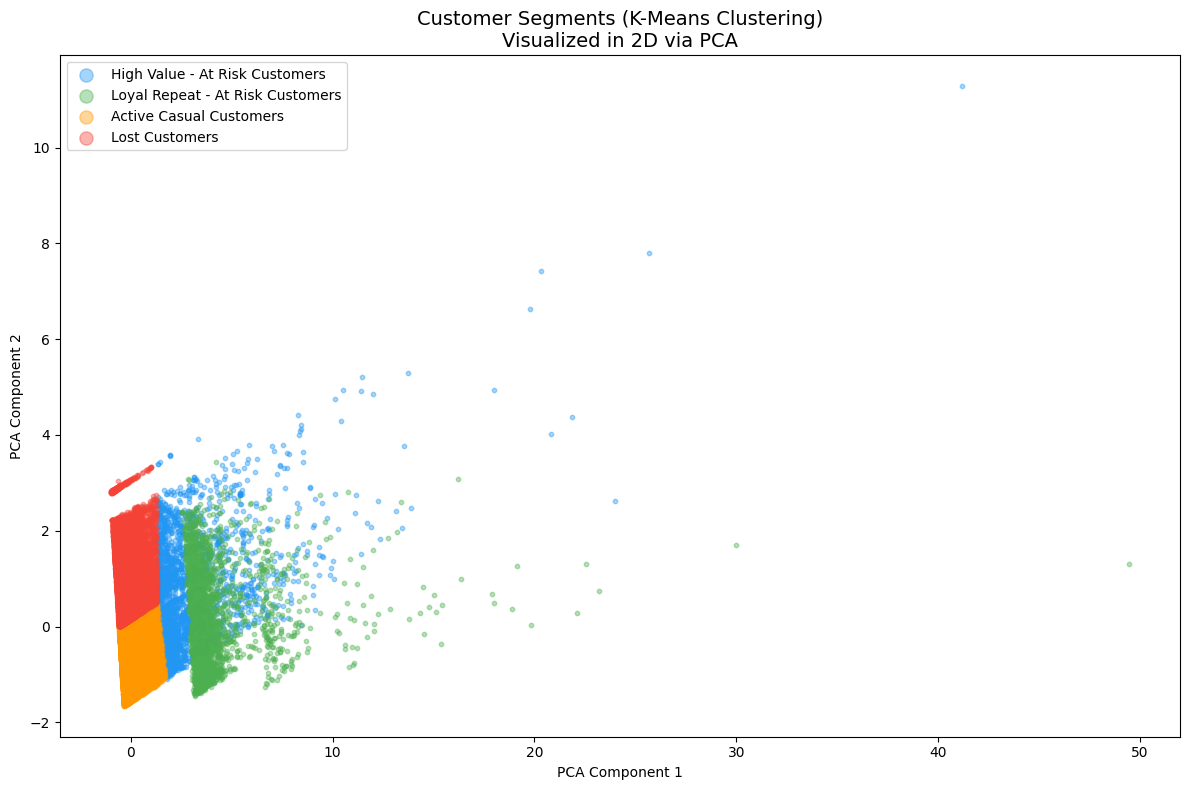

In [13]:
# VISUALIZE CLUSTERS WITH PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
rfm_2d = pca.fit_transform(rfm_scaled)

print(f"Variance explained by 2 PCA components: {pca.explained_variance_ratio_.sum()*100:.1f}%")
# If this is above 70%, our 2D plot captures most of the cluster structure

plt.figure(figsize=(12, 8))
colors = {'High Value - At Risk Customers': '#2196F3', 'Loyal Repeat - At Risk Customers': '#4CAF50', 'Active Casual Customers': '#FF9800', 'Lost Customers': '#F44336'}

for segment, color in colors.items():
    mask = customer_features['segment'] == segment
    if mask.any():
        plt.scatter(rfm_2d[mask, 0], rfm_2d[mask, 1],
                   c=color, alpha=0.4, s=10, label=segment)

plt.title('Customer Segments (K-Means Clustering)\nVisualized in 2D via PCA', fontsize=14)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(markerscale=3)
plt.tight_layout()
plt.savefig('kmeans_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

 The 70.8% variance explained means this 2D view captures roughly 70% of the real cluster structure — good enough to trust the visual, but not perfect.
Think of it like a shadow of a 3D object — the shadow gives you a rough shape but loses some detail.
What the plot is telling, cluster by cluster
Orange — Active Casual Customers (bottom-left, tight vertical strip)

Sitting at the far left on Component 1 and clustered tightly. Low PCA-1 value means low spend and low frequency — these are your recent, average-spending, one-time buyers. The tight grouping tells you they're very homogeneous — nearly all identical in behaviour, which makes sense since they're all first-time buyers who haven't churned yet.
Red — Lost Customers (left side, slightly above orange)

Also tight and clustered at low PCA-1, sitting just above orange. Very similar spend/frequency profile to Active Casual, which is why they're geographically close — the only thing separating them from orange is recency (they bought a long time ago). The fact that red and orange are almost overlapping in this 2D view is important: it means the PCA is struggling to separate them visually because recency is the third dimension that PCA is compressing away. In actual 3D RFM space they're more separated than they look here.
Blue — High Value At-Risk Customers (spreads far right)

This is your most visually striking cluster. Blue dots start at low PCA-1 but spread dramatically to the right all the way to PCA-1 = 50. That rightward spread represents high spend — PCA Component 1 is primarily capturing total spend, and these customers have very high monetary values. The wide spread within the blue cluster tells you this group is heterogeneous — some are moderately high spenders, some are extreme outliers (the dots at x=40-50 are your very highest spenders). They're "at risk" because despite spending a lot historically, they haven't returned.
Green — Loyal Repeat At-Risk Customers (spreads right, overlaps blue)

Green also spreads rightward but not as far as blue. This is your repeat buyer group (avg_orders = 2.11) — they appear to the right because frequency and spend are both elevated relative to orange and red. The significant overlap between green and blue is the most important observation in this entire plot — it means K-Means found these two groups to be geometrically close in RFM space, differing mainly in frequency (green bought more times, blue spent more per order). In 3D they're separated, but PCA's compression puts them on top of each other here.
The three structural insights this plot gives you
1. The data is fundamentally left-skewed with outliers pulling right.

The vast majority of all four clusters pile up on the left (PCA-1 = 0 to 10), with a long sparse tail of blue high-value customers stretching to PCA-1 = 50. This visually confirms what I found in SQL — most customers are low-spend one-time buyers, with a small tail of high-value customers.

2. Red and orange are barely separable in 2D.

Their near-overlap confirms that Lost and Active Casual customers are only distinguished by recency — their spend and frequency are nearly identical. This is meaningful for your model: recency will be a very strong feature specifically for separating these two groups, and the churn model needs to lean heavily on it.

3. Green and blue overlap significantly.

This is the honest limitation of K=4 on this dataset. The "Loyal Repeat" and "High Value At-Risk" segments are not cleanly separated even by K-Means — the algorithm found them as distinct clusters in 3D, but they bleed into each other. In practical business terms: some customers in these two groups would reasonably belong to either segment, which is fine — the boundary between "high-spending first-timer" and "moderate-spending repeat buyer" is genuinely ambiguous.

In [14]:
#  SEGMENT REVENUE BREAKDOWN (KEY BUSINESS FINDING)

segment_summary = customer_features.groupby('segment').agg(customers=('customer_unique_id', 'count'),total_revenue=('total_spend', 'sum'),
    avg_spend=('total_spend', 'mean'), avg_orders=('total_orders', 'mean'), churn_rate=('churned', 'mean')).round(2)

segment_summary['pct_customers'] = (segment_summary['customers'] / segment_summary['customers'].sum() * 100).round(1)
segment_summary['pct_revenue'] = (segment_summary['total_revenue'] / segment_summary['total_revenue'].sum() * 100).round(1)

print(segment_summary.to_string())

# Save for Power BI
segment_summary.reset_index().to_csv('segment_summary.csv', index=False)
customer_features.to_csv('customer_features_with_segments.csv', index=False)
print("\nSaved segment files for Power BI")

                                  customers  total_revenue  avg_spend  avg_orders  churn_rate  pct_customers  pct_revenue
segment                                                                                                                  
Active Casual Customers               50636     6803210.57     134.36        1.00        0.29           54.2         44.1
High Value - At Risk Customers         2418     2807071.54    1160.91        1.01        0.58            2.6         18.2
Lost Customers                        37524     5007950.54     133.46        1.00        1.00           40.2         32.5
Loyal Repeat - At Risk Customers       2772      802993.66     289.68        2.11        0.56            3.0          5.2

Saved segment files for Power BI


In [15]:
segment_summary.head()

,customers,total_revenue,avg_spend,avg_orders,churn_rate,pct_customers,pct_revenue
segment,,,,,,,
Active Casual Customers,50636,6803210.57,134.36,1.00,0.29,54.2,44.1
High Value - At Risk Customers,2418,2807071.54,1160.91,1.01,0.58,2.6,18.2
Lost Customers,37524,5007950.54,133.46,1.00,1.00,40.2,32.5
Loyal Repeat - At Risk Customers,2772,802993.66,289.68,2.11,0.56,3.0,5.2


1. Active Casual Customers

54.2% of customers | 44.1% of revenue | Churn = 29%

My Interpretation
This is the largest customer segment in the business.
These customers spend a moderate amount (~134 BRL on average).
Most have only purchased once, but many are still relatively active compared to other segments.
I see this group as the biggest opportunity for future growth.
Why It Matters
Since this segment represents more than half of all customers, even a small increase in repeat purchases could generate a significant revenue uplift.
My Recommendation
I would focus on converting these customers into repeat buyers through personalized recommendations and post-purchase offers.
Encouraging a second purchase should be the primary goal for this segment.
2. High Value – At Risk Customers

2. 6% of customers | 18.2% of revenue | Churn = 58%

My Interpretation
This is a very small segment, but they contribute a disproportionately large share of revenue.
Their average spend (~1161 BRL) is far higher than any other group.
However, many of them have become inactive recently, making them a high-risk segment.
Why It Matters
Losing even a small number of these customers can have a noticeable impact on revenue.
In my view, these are the customers the business should prioritize protecting.
My Recommendation
I would run targeted win-back campaigns and provide VIP-style incentives.
Personalized communication and exclusive offers could help bring these customers back.

3. Lost Customers

40.2% of customers | 32.5% of revenue | Churn = 100%

My Interpretation
This segment consists of customers who appear to be completely inactive.
Most are low-spending, one-time buyers who never returned.
They represent a large share of customers but provide relatively low value on an individual basis.
Why It Matters
While the segment is large, the likelihood of successfully reactivating many of these customers is relatively low, this is what the dataset suggests.
My Recommendation
I would run a low-cost re-engagement campaign.
If customers do not respond, I would shift resources toward higher-value segments and acquiring new customers ( as this is waht the dataset suggests) instead.

4. Loyal Repeat – At Risk Customers

3.0% of customers | 5.2% of revenue | Avg Orders = 2.11 | Churn = 56%

My Interpretation
This is one of the few segments that demonstrates genuine repeat-purchase behavior.
These customers have already shown a willingness to return and purchase again.
However, many are now becoming inactive.
Why It Matters
Retaining an existing repeat customer is generally easier and cheaper than acquiring a new one.
This segment already has a proven history of engagement.
My Recommendation
I would proactively target these customers before they become fully inactive.
Loyalty rewards, reminders, and personalized offers could help improve retention

In [16]:
customer_features.head()

,customer_unique_id,total_orders,total_spend,avg_order_value,max_order_value,min_order_value,first_purchase,last_purchase,avg_review_score,min_review_score,...,state,recency_days,customer_age_days,avg_days_between_orders,order_value_range,spend_per_active_day,churned,has_repeat_orders,cluster,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,141.90,141.90,2018-05-10 10:56:27,2018-05-10 10:56:27,5.0,5.0,...,SP,111,1,NaN,141.90,141.90,0,0,0,Active Casual Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,27.19,27.19,2018-05-07 11:11:27,2018-05-07 11:11:27,4.0,4.0,...,SP,114,1,NaN,27.19,27.19,0,0,0,Active Casual Customers
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,86.22,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03,3.0,3.0,...,SC,536,1,NaN,86.22,86.22,1,0,1,Lost Customers
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,43.62,43.62,2017-10-12 20:29:41,2017-10-12 20:29:41,4.0,4.0,...,PA,320,1,NaN,43.62,43.62,1,0,1,Lost Customers
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,196.89,196.89,2017-11-14 19:45:42,2017-11-14 19:45:42,5.0,5.0,...,SP,287,1,NaN,196.89,196.89,1,0,1,Lost Customers


In [9]:
customer_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93350 entries, 0 to 93349
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               93350 non-null  int64  
 1   customer_unique_id       93350 non-null  object 
 2   total_orders             93350 non-null  int64  
 3   total_spend              93350 non-null  float64
 4   avg_order_value          93350 non-null  float64
 5   max_order_value          93350 non-null  float64
 6   min_order_value          93350 non-null  float64
 7   first_purchase           93350 non-null  object 
 8   last_purchase            93350 non-null  object 
 9   avg_review_score         92747 non-null  float64
 10  min_review_score         92747 non-null  float64
 11  avg_delivery_days        93350 non-null  float64
 12  pct_on_time              93350 non-null  float64
 13  favorite_category        93350 non-null  object 
 14  num_categories        